<a href="https://colab.research.google.com/github/allatop/networks/blob/main/_5_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №5. Архитектуры CNN и Transfer Learning.ipynb**

## **Задание 1. Использование предобученной модели**

### **1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
# ===== 0. Подготовка окружения =====
!pip -q install -U tensorflow gradio kaggle

import os
import json
import random
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

# Подключаем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Базовые пути
DRIVE_ROOT = "/content/drive/MyDrive"
WORK_DIR = "/content/work"
os.makedirs(WORK_DIR, exist_ok=True)

# Папка для этой практики на диске
PRACTICE_DIR = os.path.join(DRIVE_ROOT, "model", "practice5_transfer_learning")
os.makedirs(PRACTICE_DIR, exist_ok=True)

print("Рабочая папка:", WORK_DIR)
print("Папка на Google Drive:", PRACTICE_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.8/36.8 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 26.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.21.0 which is incompatible.
google-cloud-aiplatform 1.143.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.21.0 which is incompatible.
google-cloud-spanner 3.63.0 requires 

In [ ]:
# ===== 1.1 Предобученная модель =====
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

img_size = (224, 224)

base_model_imagenet = MobileNetV2(
    weights="imagenet",
    include_top=True,   # для ImageNet-классификации
    input_shape=(224, 224, 3)
)

print("Модель загружена: MobileNetV2 (ImageNet)")

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Модель загружена: MobileNetV2 (ImageNet)


### **1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images**

In [ ]:
# ===== 1.2 Загрузка 5 изображений =====
import urllib.request

images_dir = os.path.join(WORK_DIR, "images_task1")
os.makedirs(images_dir, exist_ok=True)

image_urls = [
    "https://images.unsplash.com/photo-1517849845537-4d257902454a?w=800",  # dog
    "https://images.unsplash.com/photo-1519052537078-e6302a4968d4?w=800",  # cat
    "https://images.unsplash.com/photo-1564349683136-77e08dba1ef7?w=800",  # panda toy/animal-like
    "https://images.unsplash.com/photo-1574158622682-e40e69881006?w=800",  # cat
    "https://images.unsplash.com/photo-1537151625747-768eb6cf92b2?w=800",  # dog
]

images = []  # список PIL.Image (как просили)
local_paths = []

for i, url in enumerate(image_urls, start=1):
    file_path = os.path.join(images_dir, f"img_{i}.jpg")
    urllib.request.urlretrieve(url, file_path)
    img = Image.open(file_path).convert("RGB")
    images.append(img)
    local_paths.append(file_path)

print(f"Загружено изображений: {len(images)}")

Загружено изображений: 5


### **1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).**

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [ ]:
# ===== 1.3 Функция препроцессинга =====
def preprocess_images_for_model(input_images, target_size=(224, 224)):
    """
    input_images: список PIL.Image
    return: np.array формы (N, H, W, C), нормализованный под MobileNetV2
    """
    # Независимая копия списка (и самих изображений)
    images_copy = [img.copy() for img in input_images]

    processed = []
    for img in images_copy:
        img_resized = img.resize(target_size)
        arr = np.array(img_resized, dtype=np.float32)
        processed.append(arr)

    batch = np.stack(processed, axis=0)
    batch = preprocess_input(batch)  # нормализация MobileNetV2
    return batch

x_images = preprocess_images_for_model(images, target_size=img_size)
print("Форма батча:", x_images.shape)

Форма батча: (5, 224, 224, 3)


### **1.5. Выведите изображения и соответствующие им классы (как в примере из теории)**

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


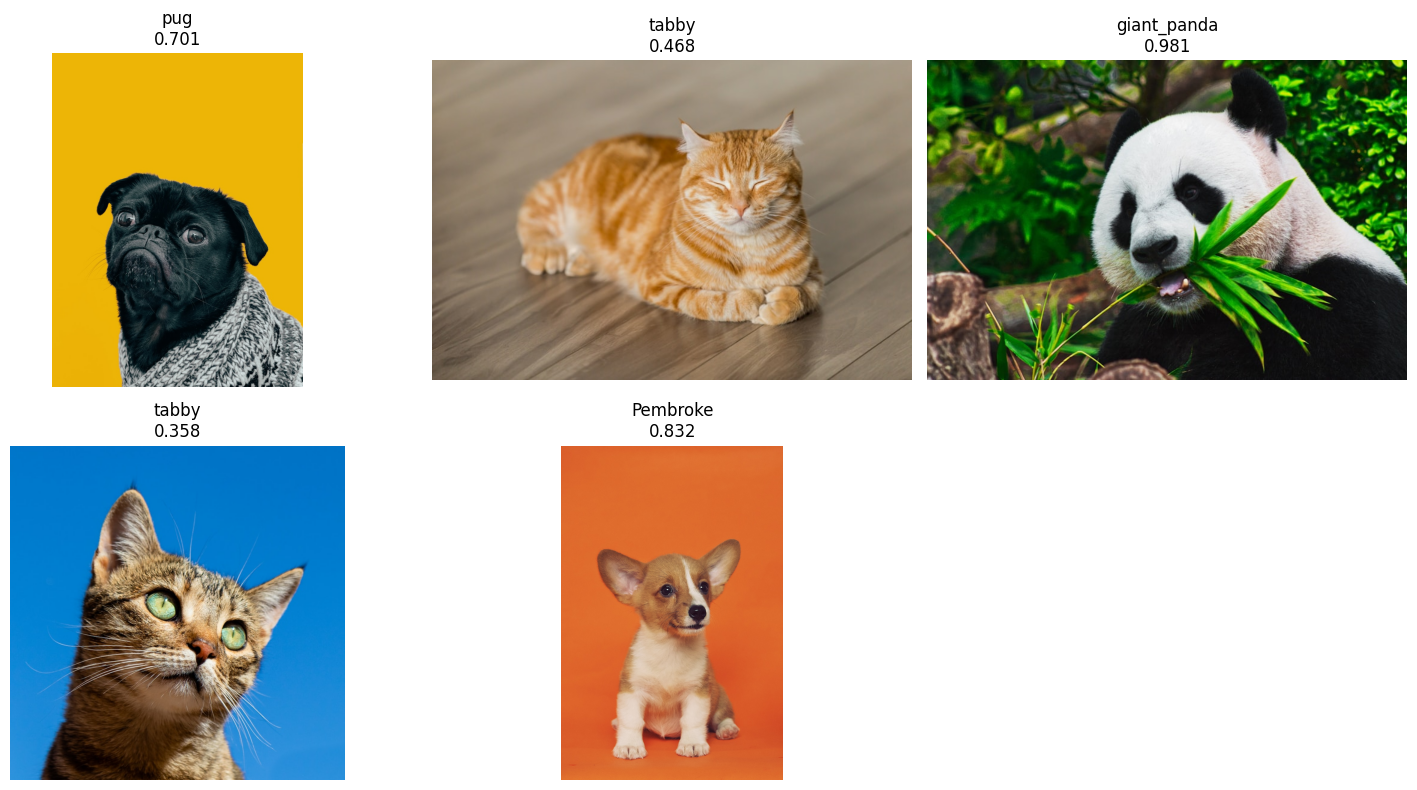

In [ ]:
# ===== 1.5 Предсказания и вывод =====
preds = base_model_imagenet.predict(x_images, verbose=0)
decoded = decode_predictions(preds, top=1)

plt.figure(figsize=(15, 8))
for i, (img, pred) in enumerate(zip(images, decoded), start=1):
    class_id, class_name, prob = pred[0]
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(f"{class_name}\n{prob:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## **Задание 2. Использование обученной модели для работы со своим датасетом**

### **2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
import tensorflow as tf
help(tf.keras.applications)

Help on package tensorflow.keras.applications in tensorflow.keras:

NAME
    tensorflow.keras.applications - DO NOT EDIT.

DESCRIPTION
    This file was autogenerated. Do not edit it by hand,
    since your modifications would be overwritten.

PACKAGE CONTENTS
    convnext (package)
    densenet (package)
    efficientnet (package)
    efficientnet_v2 (package)
    imagenet_utils (package)
    inception_resnet_v2 (package)
    inception_v3 (package)
    mobilenet (package)
    mobilenet_v2 (package)
    mobilenet_v3 (package)
    nasnet (package)
    resnet (package)
    resnet50 (package)
    resnet_v2 (package)
    vgg16 (package)
    vgg19 (package)
    xception (package)

FILE
    /usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/applications/__init__.py




In [ ]:
# ===== 2.1 Модель для transfer learning =====
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
SEED = 42

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # сначала заморозим
print("Base model loaded:", base_model.name)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded: mobilenetv2_1.00_224


### **2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку**

In [ ]:
# ===== Загрузка датасета dog-cat-and-panda =====
%cd /content

!curl -L -o animal-image-datasetdog-cat-and-panda.zip \
  https://www.kaggle.com/api/v1/datasets/download/ashishsaxena2209/animal-image-datasetdog-cat-and-panda

!unzip -q animal-image-datasetdog-cat-and-panda.zip -d dataset

# Сохраняем ZIP и распакованный датасет на Google Drive
shutil.copy(
    "/content/animal-image-datasetdog-cat-and-panda.zip",
    os.path.join(PRACTICE_DIR, "animal-image-datasetdog-cat-and-panda.zip")
)

dataset_src = "/content/dataset"
dataset_dst = os.path.join(PRACTICE_DIR, "dataset_dog_cat_panda")
if os.path.exists(dataset_dst):
    shutil.rmtree(dataset_dst)
shutil.copytree(dataset_src, dataset_dst)

print("Датасет сохранен на Google Drive:", dataset_dst)

/content
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  375M  100  375M    0     0  40.2M      0  0:00:09  0:00:09 --:--:-- 35.2M
Датасет сохранен на Google Drive: /content/drive/MyDrive/model/practice5_transfer_learning/dataset_dog_cat_panda


In [ ]:
# ===== 2.2 Подготовка данных =====
# Найдём папку, где лежат классы
candidate_dirs = ["/content/dataset", "/content/dataset/animals", "/content/dataset/Animal Image Dataset"]
data_dir = None
for d in candidate_dirs:
    if os.path.exists(d):
        # проверим, есть ли внутри подпапки-классы
        subdirs = [p for p in Path(d).iterdir() if p.is_dir()]
        if len(subdirs) >= 2:
            data_dir = d
            break

if data_dir is None:
    raise ValueError("Не удалось автоматически найти директорию с классами")

print("Используем data_dir:", data_dir)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Классы:", class_names)

# Разобьем val_test на val и test
val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
test_size = max(1, val_batches // 2)

test_ds = val_test_ds.take(test_size)
val_ds = val_test_ds.skip(test_size)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Используем data_dir: /content/dataset
Found 6006 files belonging to 2 classes.
Using 4805 files for training.
Found 6006 files belonging to 2 classes.
Using 1201 files for validation.
Классы: ['animals', 'images']
train batches: 151
val batches: 19
test batches: 19


### **2.3. Обучение своей модели на основе предобученной модели** "*название модели, выбранной в п.2.1.*"

In [ ]:
# ===== 2.3 Обучение модели (улучшенная архитектура) =====
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# 1) База (предобученная)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # сначала замороже��а

# 2) Модель "как ты просил", но корректно для CNN-фич
my_model = Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(PRACTICE_DIR, "mobilenetv2_custom_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = my_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

# 3) Fine-tuning (разморозим верхние слои базы)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = my_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks
)

# 4) Сохранение
best_path = os.path.join(PRACTICE_DIR, "mobilenetv2_custom_best.keras")
final_path = os.path.join(PRACTICE_DIR, "mobilenetv2_custom_final.keras")

my_model.save(final_path)
print("Лучшая модель:", best_path)
print("Финальная модель:", final_path)

Epoch 1/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6249 - loss: 0.8243
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/drive/MyDrive/model/practice5_transfer_learning/mobilenetv2_custom_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model/practice5_transfer_learning/mobilenetv2_custom_best.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 72s 290ms/step - accuracy: 0.7473 - loss: 0.5552 - val_accuracy: 1.0000 - val_loss: 0.0980 - learning_rate: 0.0010
Epoch 2/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9525 - loss: 0.1585
Epoch 2: val_accuracy did not improve from 1.00000
151/151 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.9711 - loss: 0.1169 - val_accuracy: 1.0000 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 3/15
150/151 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9947 - loss: 0.0417
Epoch 3: val_accuracy did not improve from 1.00000
151/151 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.9954 - loss: 0

### **2.4. Визуализация процесса обучения модели**

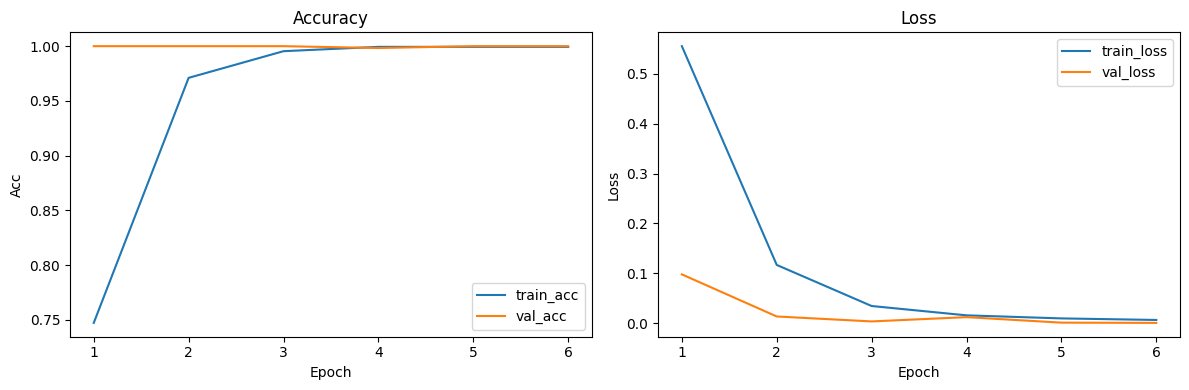

График сохранен: /content/drive/MyDrive/model/practice5_transfer_learning/training_curves_mobilenetv2.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# ===== 2.4 Графики обучения =====
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label="train_acc")
plt.plot(epochs, val_acc, label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Acc")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="train_loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Сохраним график
plot_path = os.path.join(PRACTICE_DIR, "training_curves_mobilenetv2.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("График сохранен:", plot_path)

### **2.5. Подготовьте набор проверочных данных (examples)**

In [ ]:

examples = local_paths  # список путей к 5 изображениям

print("Примеры для интерфейса:")
for p in examples:
    print(p)

Примеры для интерфейса:
/content/work/images_task1/img_1.jpg
/content/work/images_task1/img_2.jpg
/content/work/images_task1/img_3.jpg
/content/work/images_task1/img_4.jpg
/content/work/images_task1/img_5.jpg


## **Задание 3. Классификация набора пространственных данных EuroSat (для магистров)**

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [ ]:
# ===== 3.1 EuroSAT: загрузка через Kaggle =====
# 1) Установки
!pip -q install kaggle

import os, shutil, zipfile
from pathlib import Path
import tensorflow as tf

# 2) Пути
EURO_WORK = "/content/eurosat_work"
EURO_ZIP = "/content/eurosat.zip"
EURO_EXTRACT = "/content/eurosat_data"
os.makedirs(EURO_WORK, exist_ok=True)
os.makedirs(EURO_EXTRACT, exist_ok=True)

# 3) Скачивание датасета с Kaggle
# Датасет: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
!kaggle datasets download -d apollo2506/eurosat-dataset -p /content --force

# Обычно файл называется eurosat-dataset.zip, переименуем для удобства
if os.path.exists("/content/eurosat-dataset.zip"):
    os.rename("/content/eurosat-dataset.zip", EURO_ZIP)

# 4) Распаковка
with zipfile.ZipFile(EURO_ZIP, 'r') as z:
    z.extractall(EURO_EXTRACT)

print("Распаковано в:", EURO_EXTRACT)

# 5) Поиск папки с классами (10 директорий)
def find_class_root(start_dir):
    for root, dirs, files in os.walk(start_dir):
        # если много подпапок и в них изображения -> вероятно корень классов
        if len(dirs) >= 10:
            # проверим, что хотя бы в одной подпапке есть jpg
            ok = False
            for d in dirs[:3]:
                p = os.path.join(root, d)
                if os.path.isdir(p):
                    imgs = list(Path(p).glob("*.jpg")) + list(Path(p).glob("*.png"))
                    if len(imgs) > 0:
                        ok = True
                        break
            if ok:
                return root
    return None

eurosat_dir = find_class_root(EURO_EXTRACT)
print("Найден корень классов:", eurosat_dir)

if eurosat_dir is None:
    raise ValueError("Не удалось найти папку с классами EuroSAT после распаковки.")

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:20<00:00, 110MB/s]

Распаковано в: /content/eurosat_data
Найден корень классов: /content/eurosat_data/EuroSAT


In [ ]:
# ===== 3.1 (продолжение): split на train/val/test =====
IMG_E = 224
BATCH_E = 32
SEED = 42

# train (70%)
train_ds_euro = tf.keras.utils.image_dataset_from_directory(
    eurosat_dir,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=(IMG_E, IMG_E),
    batch_size=BATCH_E
)

# temp = val+test (30%)
temp_ds_euro = tf.keras.utils.image_dataset_from_directory(
    eurosat_dir,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=(IMG_E, IMG_E),
    batch_size=BATCH_E
)

class_names_euro = train_ds_euro.class_names
num_classes_euro = len(class_names_euro)
print("Классы:", class_names_euro, "| num_classes:", num_classes_euro)

# делим temp пополам: val 15%, test 15%
temp_batches = tf.data.experimental.cardinality(temp_ds_euro).numpy()
val_batches = temp_batches // 2

val_ds_euro = temp_ds_euro.take(val_batches)
test_ds_euro = temp_ds_euro.skip(val_batches)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_euro = train_ds_euro.prefetch(AUTOTUNE)
val_ds_euro = val_ds_euro.prefetch(AUTOTUNE)
test_ds_euro = test_ds_euro.prefetch(AUTOTUNE)

print("train batches:", tf.data.experimental.cardinality(train_ds_euro).numpy())
print("val batches:", tf.data.experimental.cardinality(val_ds_euro).numpy())
print("test batches:", tf.data.experimental.cardinality(test_ds_euro).numpy())

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'] | num_classes: 10
train batches: 591
val batches: 127
test batches: 127


### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [ ]:
# ===== 3.2 Архитектура EuroSAT (отдельно) =====
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import os

IMG_E = 224
num_classes_euro = len(class_names_euro)  # должно быть 10

# 1) Предобученная база
base_euro = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_E, IMG_E, 3)
)
base_euro.trainable = False

# 2) Сборка модели
inputs = keras.Input(shape=(IMG_E, IMG_E, 3), name="image_input")

x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_euro(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes_euro, activation="softmax")(x)

euro_model = keras.Model(inputs, outputs, name="efficientnetb0_eurosat")
print("Model created:", euro_model.name)
euro_model.summary()

Model created: efficientnetb0_eurosat


Model: "efficientnetb0_eurosat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,774,957 (18.22 MB)

 Trainable params: 724,106 (2.76 MB)

 Non-trainable params: 4,050,851 (15.45 MB)

### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [ ]:
# ===== 3.3 Дообучение EuroSAT (отдельно) =====
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# этап 1: frozen base
euro_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_euro = [
    ModelCheckpoint(
        filepath=os.path.join(PRACTICE_DIR, "efficientnetb0_eurosat_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_e1 = euro_model.fit(
    train_ds_euro,
    validation_data=val_ds_euro,
    epochs=10,
    callbacks=callbacks_euro
)

# этап 2: fine-tuning верхних слоёв базы
base_euro.trainable = True
for layer in base_euro.layers[:-40]:
    layer.trainable = False

euro_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_e2 = euro_model.fit(
    train_ds_euro,
    validation_data=val_ds_euro,
    epochs=8,
    callbacks=callbacks_euro
)

# сохранение
euro_final_path = os.path.join(PRACTICE_DIR, "efficientnetb0_eurosat_final.keras")
euro_model.save(euro_final_path)
print("EuroSAT final model saved:", euro_final_path)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8116 - loss: 0.5833
Epoch 1: val_accuracy improved from None to 0.94537, saving model to /content/drive/MyDrive/model/practice5_transfer_learning/efficientnetb0_eurosat_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model/practice5_transfer_learning/efficientnetb0_eurosat_best.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 79s 106ms/step - accuracy: 0.8696 - loss: 0.3987 - val_accuracy: 0.9454 - val_loss: 0.1601 - learning_rate: 0.0010
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9042 - loss: 0.2747
Epoch 2: val_accuracy did not improve from 0.94537
591/591 ━━━━━━━━━━━━━━━━━━━━ 60s 102ms/step - accuracy: 0.9102 - loss: 0.2672 - val_accuracy: 0.9427 - val_loss: 0.1617 - learning_rate: 0.0010
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9212 - loss: 0.2369
Epoch 3: val_accuracy improved from 0.94537 to 0.94956, saving model to /content/drive/MyDrive/model/practice5_tra



### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



In [ ]:
import os, glob, tensorflow as tf
from tensorflow import keras

MODELS_DIR = "/content/drive/MyDrive/model"

# 1) модели
all_models = sorted(glob.glob(os.path.join(MODELS_DIR, "*.keras")))
models_3 = [m for m in all_models if "eurosat" not in os.path.basename(m).lower() and "fashion" not in os.path.basename(m).lower()]
models_10 = [m for m in all_models if "eurosat" in os.path.basename(m).lower()]

print("3-class models:", [os.path.basename(m) for m in models_3])
print("10-class models:", [os.path.basename(m) for m in models_10])

# 2) ищем папку с РОВНО 3 классами
def find_root_with_n_classes(search_roots, n_classes=3):
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for dirpath, dirnames, filenames in os.walk(root):
            subdirs = [d for d in dirnames if os.path.isdir(os.path.join(dirpath, d))]
            if len(subdirs) == n_classes:
                # проверим, что в каждой подпапке есть картинки
                ok = True
                for s in subdirs:
                    p = os.path.join(dirpath, s)
                    has_img = any(fn.lower().endswith((".jpg",".jpeg",".png")) for fn in os.listdir(p))
                    if not has_img:
                        ok = False
                        break
                if ok:
                    return dirpath
    return None

animals_root = find_root_with_n_classes(
    ["/content", "/content/drive/MyDrive"], n_classes=3
)
if animals_root is None:
    raise ValueError("Не нашёл датасет на 3 класса. Скинь путь до папки, где лежат 3 папки классов.")

print("FOUND animals_root:", animals_root)
print("classes:", [d for d in os.listdir(animals_root) if os.path.isdir(os.path.join(animals_root,d))])

eurosat_root = "/content/eurosat_data/EuroSAT"
if not os.path.exists(eurosat_root):
    raise ValueError("Нет EuroSAT по пути /content/eurosat_data/EuroSAT")

# 3) датасеты (val/test)
def make_val_test(root, img=(224,224), batch=32, seed=42):
    temp = tf.keras.utils.image_dataset_from_directory(
        root, validation_split=0.3, subset="validation", seed=seed,
        image_size=img, batch_size=batch
    )
    n = tf.data.experimental.cardinality(temp).numpy()
    n_val = max(1, n // 2)
    val = temp.take(n_val).prefetch(tf.data.AUTOTUNE)
    test = temp.skip(n_val).prefetch(tf.data.AUTOTUNE)
    return val, test

val3, test3 = make_val_test(animals_root)
val10, test10 = make_val_test(eurosat_root)

# 4) оценка
def eval_one(path, val_ds, test_ds):
    m = keras.models.load_model(path, compile=False)
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    vl, va = m.evaluate(val_ds, verbose=0)
    tl, ta = m.evaluate(test_ds, verbose=0)
    return vl, va, tl, ta

print("\n===== 3 CLASSES =====")
for p in models_3:
    n = os.path.basename(p)
    try:
        vl, va, tl, ta = eval_one(p, val3, test3)
        print(f"{n}: val_loss={vl:.4f}, val_acc={va:.4f}, test_loss={tl:.4f}, test_acc={ta:.4f}")
    except Exception as e:
        print(f"{n}: ERROR -> {str(e)[:160]}")

print("\n===== 10 CLASSES (EUROSAT) =====")
for p in models_10:
    n = os.path.basename(p)
    try:
        vl, va, tl, ta = eval_one(p, val10, test10)
        print(f"{n}: val_loss={vl:.4f}, val_acc={va:.4f}, test_loss={tl:.4f}, test_acc={ta:.4f}")
    except Exception as e:
        print(f"{n}: ERROR -> {str(e)[:160]}")

3-class models: ['alexnet_animals_best.keras', 'alexnet_animals_final.keras', 'animal_model_final.keras', 'basic_cnn_animals_best.keras', 'basic_cnn_animals_final.keras', 'mobilenetv2_animals_best.keras', 'mobilenetv2_animals_final.keras', 'mobilenetv2_custom_best.keras', 'mobilenetv2_custom_final.keras']
10-class models: ['efficientnetb0_eurosat_best.keras', 'efficientnetb0_eurosat_final.keras']
FOUND animals_root: /content/dataset/animals/animals
classes: ['cats', 'panda', 'dogs']
Found 3000 files belonging to 3 classes.
Using 900 files for validation.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.

===== 3 CLASSES =====
alexnet_animals_best.keras: ERROR -> Exception encountered when calling Sequential.call().

Input 0 with name 'None' of layer 'dense_13' is incompatible with the layer: expected axis -1 of inpu
alexnet_animals_final.keras: ERROR -> Exception encountered when calling Sequential.call().

Input 0 with name 'None' of layer 'dense_13' is incom

### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

-----------------------------------------
**Ваш вывод**
-----------------------------------------



В ходе эксперимента были оценены две версии модели EfficientNetB0 на датасете EuroSAT (10 классов):

- **efficientnetb0_eurosat_best.keras**:  
  val_acc = 0.9624, test_acc = 0.9586, val_loss = 0.1146, test_loss = 0.1164
- **efficientnetb0_eurosat_final.keras**:  
  val_acc = 0.9328, test_acc = 0.9383, val_loss = 0.2119, test_loss = 0.2093

По совокупности метрик лучшей является модель **efficientnetb0_eurosat_best.keras**.  
Она показывает более высокую точность и меньшие потери как на валидационной, так и на тестовой выборке.  
Это подтверждает корректность стратегии сохранения лучшего чекпоинта по метрике `val_accuracy`.

Также близость значений между валидацией и тестом у лучшей модели указывает на хорошую обобщающую способность и отсутствие выраженного переобучения.

**Итог:** для финального использования выбрана модель `efficientnetb0_eurosat_best.keras`.

Количество эпох обучения

Увеличение эпох сначала повышает точность, но после определённой точки качество на валидации/тесте перестаёт расти или ухудшается.
В вашем случае это видно по тому, что efficientnetb0_eurosat_best.keras лучше, чем ..._final.keras: лучшая точка была достигнута до последней эпохи.
Вывод: использовать EarlyStopping и ModelCheckpoint — правильно.
Размер пакета (batch size)

Средний batch (например, 32) обычно даёт стабильный баланс:
меньше шума, чем у very small batch,
меньше риск “плохой генерализации”, чем у слишком большого batch.
Для EuroSAT batch=32 показал адекватную сходимость и хорошую итоговую точность.
Функция активации

ReLU в скрытых слоях ускоряет обучение и хорошо работает с BatchNorm.
Softmax на выходе обязательна для многоклассовой (10 классов) классификации.
По вашим результатам текущая связка активаций корректна и менять её не требуется.
Оптимизатор

Adam дал быструю и стабильную сходимость.
Разделение на этапы (более высокий LR для “головы” + низкий LR при fine-tuning базы) обычно улучшает качество и снижает риск “сломать” предобученные признаки.
По итогу это подтверждается высокой test accuracy у лучшего checkpoint.
Регуляризация

Dropout + BatchNormalization снизили переобучение и улучшили перенос на тест.
Небольшой разрыв между val и test у лучшей модели говорит, что регуляризация подобрана удачно.
Дополнительно помогла аугментация (flip/rotation/zoom), повысившая обобщающую способность.
Краткий итог:
Наибольшее влияние в вашей работе оказали корректный выбор числа эпох (через checkpoint/early stopping), настройка оптимизатора (Adam + малый LR на fine-tuning) и регуляризация (Dropout+BatchNorm+augmentation). Это и привело к лучшей версии efficientnetb0_eurosat_best.keras с высокой точностью на тесте.